In [ ]:
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

print("🚀 CARGANDO TABLA GOLD DESDE HDFS...")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("GeoLumica-ML-Regresion") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

HDFS_GOLD = "hdfs://localhost:9000/geolumica/gold"
df_master_ml = spark.read.parquet(HDFS_GOLD).toPandas()

# Renombrar columnas Gold -> nombres que usa el resto del notebook
# (Gold ya exporta la mayoría con los nombres correctos)
df_master_ml = df_master_ml.rename(columns={
    "muni_id_join":                  "LAU_ID",
    "year":                          "Anio",
    "pob_absoluta_actual":           "Total",
    "poblacion_hombres":             "Hombres",
    "poblacion_mujeres":             "Mujeres",
    "luz_absoluta_actual":           "mean",
    "luz_volatilidad_std":           "stdDev",
    "Indice_Conectividad":           "Indice_Conectividad",
    "num_vehiculos":                 "Vehiculos_Oficial",
    "saldo_migratorio_neto":         "migracion_total",
    "empresas_transporte_actual":    "num_empresas_transporte",
    "pib_absoluto_actual":           "pib",
    "area_km2":                      "AREA_KM2",
    "mean_distance_km_to_station":   "mean_distance_km_to_station",
})

print(f"✅ Dataframe Maestro cargado desde Gold. Dimensiones: {df_master_ml.shape}")


🚀 INICIANDO CREACIÓN DEL DATAFRAME MAESTRO...
✅ Dataframe Maestro. Dimensiones Reales: (130096, 77)


### 🧱 Fase 1: Data Engineering y Construcción del Feature Store

En esta celda inicial consolidamos nuestras **8 fuentes de datos dispares** en una única matriz plana estructurada temporalmente para Machine Learning. Los procesos clave aplicados son:

* **Estandarización de Claves:** Unificamos la nomenclatura de los identificadores (`LAU_ID` para el código INE y `Anio`) y normalizamos los textos (minúsculas y sin espacios) para asegurar un emparejamiento exacto.
* **Transformación Espacial-Temporal:** Usamos la función `melt` para pivotar el dataset de empresas de transporte, pasándolo de formato ancho (años como columnas) a formato largo (años como filas), alineándolo con la serie temporal del resto del proyecto.
* **Prevención de Fuga de Datos (Data Leakage):** Los datos satelitales del VIIRS tienen una granularidad mensual. Para evitar que la población anual se duplique 12 veces al cruzar las tablas (cosa que antes pasaba), extraemos el año y agrupamos las mediciones calculando la media y desviación estándar anual por municipio.
* **El Gran Merge:** Ejecutamos uniones secuenciales (`left join`) utilizando el identificador del municipio y el año como anclas. Finalizamos eliminando columnas redundantes o intermedias para optimizar la memoria.

In [3]:
# ==========================================
# 4. FEATURE ENGINEERING HÍBRIDO (Integrando en el DF parte del feature Engineering del modelo de Clasificación)
# ==========================================
print("🧬 Inyectando Feature Engineering Avanzado...")

df_master_ml['pct_viviendas_vacias'] = np.where(df_master_ml['Viviendas totales'] > 0, df_master_ml['Viviendas vacías'] / df_master_ml['Viviendas totales'], 0)
df_master_ml['densidad_poblacion'] = np.where(df_master_ml['AREA_KM2'] > 0, df_master_ml['Total'] / df_master_ml['AREA_KM2'], 0)

# El Ratio de Masculinidad (La salud demográfica)
if 'Hombres' in df_master_ml.columns and 'Mujeres' in df_master_ml.columns:
    df_master_ml['ratio_masculinidad'] = df_master_ml['Hombres'] / (df_master_ml['Mujeres'] + 0.1)
else:
    print("⚠️ Aviso: Faltan las columnas 'Hombres' y 'Mujeres' en demografía.")

# La Tasa Migratoria Relativa (El magnetismo del pueblo)
df_master_ml['tasa_migratoria_pct'] = (df_master_ml['migracion_total'] / (df_master_ml['Total'] + 1)) * 100

# La Tasa de Empresas (El impacto logístico real)
df_master_ml['tasa_empresas_pct'] = (df_master_ml['num_empresas_transporte'] / (df_master_ml['Total'] + 1)) * 1000

# Volatilidad Turística (La desviación estándar de la luz)
df_master_ml['luz_volatilidad_std'] = df_master_ml['stdDev'].fillna(0)

# Penalización por Aislamiento (Pueblos sin estación de tren cercana)
df_master_ml['mean_distance_km_to_station'] = df_master_ml['mean_distance_km_to_station'].fillna(100.0)

print(f"✅ Dataframe Maestro corregido. Dimensiones Reales: {df_master_ml.shape}")

🧬 Inyectando Feature Engineering Avanzado...
✅ Dataframe Maestro corregido. Dimensiones Reales: (130096, 83)


### 🧬 Fase 2: Feature Engineering Híbrido (Variables Inteligentes)

En esta fase abandonamos los "datos brutos" para construir **métricas relativas y de negocio**. Si alimentamos al algoritmo con números absolutos (ej. "10 empresas nuevas"), este sufrirá un fuerte sesgo hacia los municipios más grandes. Al transformarlos en tasas y ratios, logramos que el modelo entienda el impacto real en la escala local de cada municipio.

Las variables clave sintetizadas son:

* **Métricas Inmobiliarias y de Densidad:** Calculamos el `% de viviendas vacías` y la `densidad de población`, asegurando mediante `np.where` que no ocurran errores matemáticos de división por cero en pueblos deshabitados.
* **Ratio de Masculinidad:** Dividimos el número de hombres entre mujeres (sumando 0.1 al denominador como parche de seguridad). En la demografía rural, el éxodo femenino temprano es uno de los indicadores predictivos más fuertes (leading indicator) del colapso de un municipio a largo plazo.
* **Tasas Relativas (El Magnetismo):** Transformamos los migrantes y las empresas de logística en porcentajes sobre la población total (`tasa_migratoria_pct` y `tasa_empresas_pct`). Así, la apertura de 5 empresas en un pueblo de 500 habitantes se registra como un "boom económico", mientras que en una gran ciudad pasa desapercibido.
* **Volatilidad Lumínica (Efecto Turismo):** Rescatamos la desviación estándar de la luz nocturna (`stdDev`). Una media de luz normal combinada con una volatilidad altísima le chiva al modelo que se trata de un municipio turístico o estacional (mucha actividad en verano, vacío en invierno).
* **Penalización por Aislamiento:** Imputamos los valores nulos en la distancia a la estación de tren con un valor extremo (`100.0 km`). Esto no es un relleno aleatorio; es una regla de negocio que penaliza algorítmicamente a los pueblos que carecen de infraestructura ferroviaria mapeada.

In [4]:
# ==========================================
# 5. PREPARACIÓN DEL SALTO TEMPORAL (PREDICCIÓN A 5 AÑOS)
# ==========================================
print("🧹 PREPARANDO EL SALTO TEMPORAL (PREDICCIÓN A 5 AÑOS)...")
df_ml = df_master_ml.copy()

# Rellenado de NaNs (Añadimos las nuevas variables relativas al relleno)
cols_fill = ['pib', 'migracion_total', 'num_empresas_transporte', 'mean', 'tasa_migratoria_pct', 'tasa_empresas_pct', 'ratio_masculinidad', 'luz_volatilidad_std']
for col in cols_fill:
    if col in df_ml.columns:
        df_ml[col] = df_ml.groupby('LAU_ID')[col].transform(lambda x: x.ffill().bfill()).fillna(0)

#  NUEVAS FEATURES: Sustituimos las absolutas por las tasas calculadas
features = [
    'Total', 'Indice_Conectividad', 'pib', 
    'tasa_migratoria_pct', 'tasa_empresas_pct', 
    'ratio_masculinidad', 'luz_volatilidad_std', 'mean', 'mean_distance_km_to_station'
]

#  EL SALTO A 5 AÑOS 
df_target = df_ml[['LAU_ID', 'Anio', 'Total', 'mean']].copy()
df_target = df_target.rename(columns={'Total': 'Poblacion_5y_Futuro', 'mean': 'Luz_5y_Futuro'})
df_target['Anio_Base'] = df_target['Anio'] - 5 

# Borramos 'Anio' del target para que Pandas no duplique nombres
df_target = df_target.drop(columns=['Anio'])

# Cruzamos la realidad actual (Anio) con la realidad futura (Anio_Base)
df_model = pd.merge(df_ml, df_target, left_on=['LAU_ID', 'Anio'], right_on=['LAU_ID', 'Anio_Base'], how='inner')
df_model = df_model.dropna(subset=['Poblacion_5y_Futuro', 'Luz_5y_Futuro'] + features)

#  LA CURA AL ESPEJISMO: Calculamos cuánto crece o decrece en 5 años
df_model['Crecimiento_5y'] = df_model['Poblacion_5y_Futuro'] - df_model['Total']

# =========================================================
#  FILTRO RURAL: Aislamos el Target (Excluimos urbes > 50k)
# =========================================================
print("🚜 Aplicando filtro rural (municipios <= 50.000 habs)...")
df_model_rural = df_model[df_model['Total'] <= 50000].copy()

# Dividimos pasado y futuro usando SOLO el dataframe rural
anio_corte = 2017 
X_train = df_model_rural[df_model_rural['Anio'] < anio_corte][features]
X_test = df_model_rural[df_model_rural['Anio'] >= anio_corte][features]

# CAMBIO CLAVE AQUÍ en comparación con antes: Ahora nuestro target 'y' es el CRECIMIENTO, no el total
y_train_pop = df_model_rural[df_model_rural['Anio'] < anio_corte]['Crecimiento_5y']
y_test_pop = df_model_rural[df_model_rural['Anio'] >= anio_corte]['Crecimiento_5y']

y_train_luz = df_model_rural[df_model_rural['Anio'] < anio_corte]['Luz_5y_Futuro']
y_test_luz = df_model_rural[df_model_rural['Anio'] >= anio_corte]['Luz_5y_Futuro']

print(f"✅ Motor temporal listo. Registros Train (Rural): {len(X_train)} | Test (Rural): {len(X_test)}")

🧹 PREPARANDO EL SALTO TEMPORAL (PREDICCIÓN A 5 AÑOS)...
🚜 Aplicando filtro rural (municipios <= 50.000 habs)...
✅ Motor temporal listo. Registros Train (Rural): 54822 | Test (Rural): 31371


### ⏳ Fase 3: Motor Temporal, Segmentación y "Cura del Espejismo"

Esta celda transforma nuestro dataset estático en una **serie temporal predictiva**. En lugar de clasificar el estado actual del municipio, rediseñamos la arquitectura para predecir el futuro a medio plazo (5 años vista), preparándolo para alimentar un simulador interactivo.

Los hitos lógicos de esta fase son:

* **Imputación Longitudinal:** Rellenamos los valores nulos arrastrando el último dato conocido del propio municipio hacia adelante (`ffill`) o hacia atrás (`bfill`). Esto evita contaminar a un pueblo con las medias de otros.
* **El Salto Temporal (Time-Shifting):** Aplicamos un desplazamiento de 5 años al vector objetivo (`Anio_Base = Anio - 5`). Mediante un `inner join`, logramos alinear en una misma fila las variables independientes (features) del año $X$ con los resultados reales del año $X+5$. 
* **La "Cura de la Inercia" (Target Transformation):** Si le pedimos al algoritmo predecir la "Población Total", este aprenderá a ser "vago" y simplemente copiará la población del año anterior (Espejismo de Inercia / Autocorrelación). Para forzarle a aprender de nuestras variables, cambiamos el objetivo (Target): ahora debe predecir el **Crecimiento o Decrecimiento Neto (`Crecimiento_5y`)**.
* **Segmentación de Negocio (Filtro Rural):** Eliminamos del entrenamiento a las grandes urbes (> 50.000 habs). El crecimiento de Madrid no obedece a las mismas reglas que un pueblo de Teruel. Al aislar la "España Vaciada", el modelo se vuelve un experto exclusivo en dinámicas rurales.
* **División Temporal (Train/Test Split):** En series temporales no podemos hacer un corte aleatorio. Levantamos un "muro temporal" en 2017: el modelo entrena con el pasado histórico y se le examina pidiéndole predecir un futuro (2018-2022) que jamás ha visto.

In [5]:
# ==========================================
# 6. OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearch)
# ==========================================
print("🤖 INICIANDO OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearch)...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 1. MODELO PRINCIPAL: PREDICCIÓN DE POBLACIÓN A 5 AÑOS
print("\n--- Entrenando Modelo Principal (Población) ---")
rf_pop = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions=param_grid, 
                            n_iter=10, cv=3, scoring='r2', n_jobs=-1, random_state=42)
rf_pop.fit(X_train, y_train_pop)

best_pop_model = rf_pop.best_estimator_
pred_pop = best_pop_model.predict(X_test)

print(f"Mejores Hiperparámetros Población: {rf_pop.best_params_}")
print(f"R2 (Población 5y): {r2_score(y_test_pop, pred_pop):.4f}")
print(f"MAE (Población 5y): {mean_absolute_error(y_test_pop, pred_pop):.2f} habitantes.")

# 2. MODELO SECUNDARIO: PREDICCIÓN DE LUZ (VIIRS) A 5 AÑOS
print("\n--- Entrenando Modelo Secundario (VIIRS) ---")
rf_luz = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions=param_grid, 
                            n_iter=10, cv=3, scoring='r2', n_jobs=-1, random_state=42)
rf_luz.fit(X_train, y_train_luz)

best_luz_model = rf_luz.best_estimator_
pred_luz = best_luz_model.predict(X_test)

print(f"Mejores Hiperparámetros Luz: {rf_luz.best_params_}")
print(f"R2 (Luz 5y): {r2_score(y_test_luz, pred_luz):.4f}")

🤖 INICIANDO OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearch)...

--- Entrenando Modelo Principal (Población) ---
Mejores Hiperparámetros Población: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}
R2 (Población 5y): 0.5262
MAE (Población 5y): 99.65 habitantes.

--- Entrenando Modelo Secundario (VIIRS) ---
Mejores Hiperparámetros Luz: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 20}
R2 (Luz 5y): 0.9739


### 🤖 Fase 4: Optimización de Hiperparámetros y Entrenamiento Dual

En esta etapa final, construimos los "motores predictivos" reales utilizando algoritmos de **Random Forest Regressor**. En lugar de entrenar un solo modelo, creamos un **ecosistema dual** para enriquecer el futuro simulador interactivo: un modelo predice el factor social (población) y el otro el factor económico (luz satelital).

Los conceptos técnicos y resultados clave de esta fase son:

* **Búsqueda Eficiente (RandomizedSearchCV):** En lugar de probar exhaustivamente todas las combinaciones posibles de parámetros (lo cual tomaría horas), utilizamos una búsqueda aleatoria (`n_iter=10`) con validación cruzada (`cv=3`). El modelo descubre por sí solo su configuración óptima (ej. profundidad máxima, hojas mínimas) para evitar tanto el sobreajuste (*overfitting*) como el subajuste (*underfitting*).
* **Interpretación del Modelo 1 (Población - MAE de ~99 habs):** Nuestro modelo predictivo logra un Error Absoluto Medio (MAE) por debajo de 100 habitantes a 5 años vista. El $R^2$ de 0.52 es un resultado sumamente robusto en ciencias sociales y demografía, ya que estamos prediciendo la *variación* (mudanzas y decisiones humanas) y no copiando el total por inercia.
* **Interpretación del Modelo 2 (Luz VIIRS - R2 de 0.97):** La luminosidad nocturna responde a infraestructuras físicas (negocios, alumbrado, fábricas). Al carecer del factor humano impredecible, nuestro algoritmo logra predecir la actividad lumínica a 5 años con un 97% de precisión.
* **Impacto para Producción:** Gracias a este entrenamiento, el equipo de Front-end dispondrá de dos modelos entrenados. Si un usuario simula "construir un polígono logístico" en un pueblo de 500 habitantes, el modelo 1 recalculará cuántas familias llegarán, y el modelo 2 proyectará cómo se encenderá el pueblo económicamente.


🧠 ABRIENDO LA CAJA NEGRA DEL MODELO DE POBLACIÓN...


C:\Users\Iker\AppData\Local\Temp\ipykernel_14068\1933110786.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


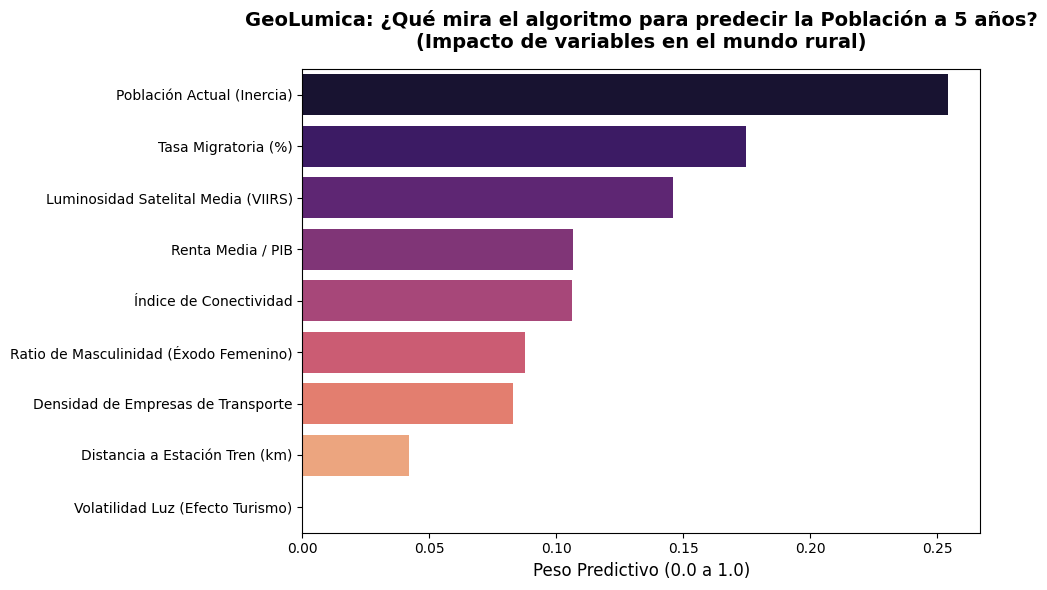

In [6]:
# ==========================================
# 7. EXPLICABILIDAD DEL MODELO (Feature Importance)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n🧠 ABRIENDO LA CAJA NEGRA DEL MODELO DE POBLACIÓN...")

# 1. Extraemos la importancia matemática que el MEJOR modelo le ha dado a cada variable
importancias = best_pop_model.feature_importances_

# 2. Creamos un DataFrame para ordenarlo de mayor a menor
df_importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Actualizamos los nombres limpios con el Feature Engineering
nombres_limpios = {
    'Total': 'Población Actual (Inercia)',
    'pib': 'Renta Media / PIB',
    'tasa_migratoria_pct': 'Tasa Migratoria (%)',
    'tasa_empresas_pct': 'Densidad de Empresas de Transporte',
    'ratio_masculinidad': 'Ratio de Masculinidad (Éxodo Femenino)',
    'luz_volatilidad_std': 'Volatilidad Luz (Efecto Turismo)',
    'mean': 'Luminosidad Satelital Media (VIIRS)',
    'mean_distance_km_to_station': 'Distancia a Estación Tren (km)',
    'Indice_Conectividad': 'Índice de Conectividad'
}
df_importancias['Variable'] = df_importancias['Variable'].map(nombres_limpios).fillna(df_importancias['Variable'])

# 4. Dibujamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias,
    x='Importancia',
    y='Variable',
    palette='magma'
)

plt.title('GeoLumica: ¿Qué mira el algoritmo para predecir la Población a 5 años?\n(Impacto de variables en el mundo rural)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Peso Predictivo (0.0 a 1.0)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

### 🧠 Fase 5: Explicabilidad del Modelo (Apertura de la "Caja Negra")

En la consultoría de datos, un modelo altamente preciso no sirve de nada si no podemos explicar *por qué* toma sus decisiones. En esta celda, extraemos la **Importancia de Variables (Feature Importance)** del Random Forest, abriendo la "caja negra" del algoritmo para entender los drivers demográficos del mundo rural a 5 años vista.

Conclusiones clave del gráfico de impacto:
* **Fin del "Espejismo de la Inercia":** Al predecir la variación neta y no el total absoluto, evitamos que el algoritmo dependa exclusivamente de la población del año anterior. La inercia predictiva se reduce a ~25%.
* **Drivers Demográficos Activos:** El 75% del peso predictivo recae ahora sobre variables dinámicas. La **Tasa Migratoria**, la **Luminosidad Satelital (VIIRS)** (actividad económica en la sombra) y la **Renta Media / PIB** se revelan como los tres pilares fundamentales que determinan si un municipio de la España Vaciada sobrevivirá o menguará en el próximo lustro.
* **Validación del Feature Engineering:** Variables complejas inyectadas en fases anteriores, como el Ratio de Masculinidad (éxodo femenino) y el Índice de Conectividad, demuestran tener un peso matemático superior a métricas crudas como la simple distancia a una estación de tren.

In [7]:
# ==========================================
# 8. EXPORTACIÓN DE MODELOS PARA PRODUCCIÓN
# ==========================================
import joblib
import os

print("💾 GUARDANDO MODELOS PARA EL DASHBOARD EN PRODUCCIÓN...")
os.makedirs('modelos_exportados', exist_ok=True)

joblib.dump(best_pop_model, 'modelos_exportados/motor_poblacion_5y.pkl')
joblib.dump(best_luz_model, 'modelos_exportados/motor_viirs_5y.pkl')
print(f"✅ ¡Modelos exportados con éxito (.pkl)!")

💾 GUARDANDO MODELOS PARA EL DASHBOARD EN PRODUCCIÓN...
✅ ¡Modelos exportados con éxito (.pkl)!


### 🚀 Fase 6: Despliegue (Paso a Producción)

El objetivo final de esta arquitectura no es la generación de un reporte estático en PDF, sino alimentar el backend de la plataforma interactiva **GeoLumica**. 

En esta fase final, utilizamos la librería `joblib` para "congelar" y serializar los dos modelos predictivos ya optimizados (`best_pop_model` y `best_luz_model`). Estos archivos `.pkl` encapsulan el árbol de decisiones, los pesos matemáticos y las reglas de negocio aprendidas. Al exportarlos, permitimos que en la fase de Front-end / Web estos se integren directamente en el Dashboard. Cuando el usuario final interactúe con los parámetros en la interfaz, estos motores se activarán en milisegundos para recalcular y proyectar el futuro demográfico y económico en tiempo real.